<a href="https://colab.research.google.com/github/Barbhuiya12/Flood_Resource/blob/main/Flood_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Does a Foundation Model Beat a U-Net at Flood Mapping?







**Siddik Barbhuiya, Vivek Gupta** |

Indian Institute of Technology Mandi

siddikbarbhuiya@gmail.com, vivekgupta@gmail.com


https://github.com/Barbhuiya12/Flood_Resource.git



### What we do here

1. Download 446 hand-labelled flood scenes.
2. Look at the data properly before modelling it.
3. Train a simple CNN and a U-Net from scratch. These are the baselines.
4. Fine-tune TerraMind, a foundation model pretrained on huge amounts of unlabelled satellite imagery.
5. Put all of them on one table and see what pretraining was worth.

### The question behind it

A foundation model costs more to run and is harder to set up. The only reason to bother is if it beats a plain U-Net. That is genuinely contested right now, so we build the U-Net first and find out rather than assume.

### Before you start

| | |
| --- | --- |
| Hardware | GPU needed. Colab: Runtime, Change runtime type, T4 |
| Data | 1.8 GB, downloads below, no account needed |
| Runtime | About 45 minutes end to end |
| Result | A working comparison, not a competitive score. Part 13 says why |

## Part 1. Setup

TerraTorch is a fine-tuning toolkit for Earth observation models, built on PyTorch Lightning. It handles three things that are otherwise weeks of work:

- attaching a task head to a pretrained encoder
- loading multiband GeoTIFFs with per-sensor normalisation
- expressing a whole training run as one YAML file, so results can be reproduced

**Set the runtime to GPU before running this.** Changing it later restarts the kernel and you lose everything.

In [1]:
!pip install "terratorch>=1.2.5"
!pip install tensorboard "setuptools<81"

Two imports worth naming:

- `albumentations` does the augmentation. It applies the same geometric transform to both sensors and the label at once, which torchvision cannot do.
- `lightning.pytorch` runs the training loop. TerraTorch does not replace it, it plugs into it.

In [2]:
import os
import torch
import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
import warnings
warnings.filterwarnings("ignore")

## Part 2. The Data

**Sen1Floods11** (Bonafilia et al., 2020): 446 hand-labelled chips, 512 by 512 pixels at 10 m, from 11 flood events on 6 continents.

| Product | What it is |
| --- | --- |
| `S1Hand` | Sentinel-1 radar, 2 bands, VV and VH, in decibels |
| `S2Hand` | Sentinel-2 optical, 13 bands |
| `LabelHand` | Human answer. `1` water, `0` dry, `-1` could not tell |

### Why radar

Radar bounces a microwave pulse off the ground and measures the echo. Calm water reflects it away like a mirror, so almost nothing returns and **water looks dark**, below about -15 dB in VV and -22 dB in VH. Radar sees through cloud and works at night, which is when floods happen.

It fails in four known ways:

- dry tarmac, sand and radar shadow are also dark, so false alarms
- flooded vegetation bounces the signal back brightly, so missed water
- wind roughens the surface and kills the mirror effect
- cities scatter the signal in every direction

### Why optical too

Sentinel-2 separates water from land far more cleanly, when it can see the ground. During a flood it usually cannot, because floods come with cloud. The two sensors fail in different situations, which is the whole argument for using both.

### The `-1` class

Not a third thing to predict. It marks pixels the annotator could not judge, mostly under cloud. They must be dropped from the loss and from the metrics. Forget this and every score you report is inflated.

### Download

1.8 GB, two to five minutes from Colab.

In [3]:
!pip install huggingface-hub
if not os.path.isdir("sen1floods11_v1.1"):
    !hf download blumenstiel/Sen1Floods11 sen1floods11_v1_1.tar.gz --repo-type dataset --local-dir ./
    !tar -xzf sen1floods11_v1_1.tar.gz

Hint: A new version of huggingface_hub (1.31.0) is available! You are using version 1.29.0.
To update, run: hf update
Hint: The `hf-cli` skill is not installed. Run `hf skills add -g --claude` to teach your AI agents how to use the `hf` CLI.

sen1floods11_v1_1.tar.gz: downloading bytes:  13% 234M/1.77G [00:02<00:06, 229MB/s, 15.6MB/s  ]
sen1floods11_v1_1.tar.gz: downloading bytes:  46% 813M/1.77G [00:03<00:02, 444MB/s, 68.6MB/s  ]
sen1floods11_v1_1.tar.gz: downloading bytes:  62% 1.09G/1.77G [00:03<00:01, 432MB/s, 89.6MB/s  ]
sen1floods11_v1_1.tar.gz: downloading bytes:  69% 1.21G/1.77G [00:04<00:01, 311MB/s, 97.9MB/s  ]
sen1floods11_v1_1.tar.gz: downloading bytes:  80% 1.77G/2.21G [00:05<00:01, 382MB/s,  131MB/s  ]
sen1floods11_v1_1.tar.gz: reconstructing file:  58% 1.02G/1.77G [00:08<00:04, 154MB/s, 34.0MB/s  ]
sen1floods11_v1_1.tar.gz: downloading bytes: 100% 1.77G/1.77G [00:18<00:00, 96.8MB/s,  133MB/s  ]
sen1floods11_v1_1.tar.gz: reconstructing file: 100% 1.77G/1.77G [00:18<00:00,

If Hugging Face is blocked on your network, use the Google Drive mirror instead. If the cell above worked, this one does nothing.

In [ ]:
!pip install gdown
import gdown
if not os.path.isdir("sen1floods11_v1.1"):
    gdown.download("https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS")
    !tar -xzf sen1floods11_v1.1.tar.gz

## Part 3. Look at the Data First

Five cells. Most surprises that later look like model failures are visible here.

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

### 3.1 What is on disk

Products, file counts, bands, size, projection.

In [7]:
dataset_path = Path("sen1floods11_v1.1")

print("Top level:")
for entry in sorted(os.listdir(dataset_path)):
    print("   ", entry)

Top level:
    Sen1Floods11_Metadata.geojson
    data
    splits


In [8]:
print("\nProducts in data/ and how many files each holds:")
inventory = []
for folder in sorted(os.listdir(dataset_path / "data")):
    files = glob.glob(str(dataset_path / "data" / folder / "*.tif"))
    if not files:
        continue
    with rasterio.open(files[0]) as src:
        inventory.append({"product": folder, "files": len(files), "bands": src.count,
                          "size": f"{src.height}x{src.width}", "dtype": src.dtypes[0],
                          "crs": str(src.crs)})
inventory = pd.DataFrame(inventory)
print(inventory.to_string(index=False))


Products in data/ and how many files each holds:
        product  files  bands    size   dtype       crs
  CopernicusDEM    446      1 512x512   int16 EPSG:4326
   JRCWaterHand    446      1 512x512   uint8 EPSG:4326
      LabelHand    446      1 512x512   int16 EPSG:4326
      S1GRDHand    446      2 512x512 float32 EPSG:4326
S1OtsuLabelHand    446      1 512x512   int16 EPSG:4326
      S2L1CHand    446     13 512x512   int16 EPSG:4326


In [9]:
print("\nSplit files:")
for split_file in sorted(glob.glob(str(dataset_path / "splits" / "*"))):
    with open(split_file) as handle:
        lines = [line for line in handle.read().split("\n") if line.strip()]
    print(f"    {os.path.basename(split_file):30s} {len(lines):4d} entries")


Split files:
    flood_bolivia_data.txt           15 entries
    flood_test_data.txt              90 entries
    flood_train_data.txt            252 entries
    flood_valid_data.txt             89 entries


### 3.2 How the splits are built

Three text files decide which chips are train, validation and test.

**The thing to check: does a country appear in more than one split?** If yes, the model trains and tests on the same flood event, and the score is optimistic. Scenes from one flood resemble each other far more than they resemble a different flood in a different biome.

That does not make the benchmark wrong, published numbers use these same splits. It changes what the number means: "generalises within events it has seen", not "transfers to a flood it has never seen".

The last line counts it for you.

In [10]:
def read_split(split_file):
    """Return the chip ids in a split file. Handles both one-name-per-line and comma-separated pairs."""
    chip_ids = []
    with open(split_file) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            first = line.split(",")[0].strip()          # some split files list image,label pairs
            stem = os.path.splitext(os.path.basename(first))[0]
            for suffix in ("_S1Hand", "_S2Hand", "_LabelHand", "_S1GRDHand", "_S2L1CHand"):
                if stem.endswith(suffix):
                    stem = stem[: -len(suffix)]
            chip_ids.append(stem)
    return chip_ids


In [11]:
splits = {}
for name, filename in [("train", "flood_train_data.txt"),
                       ("val", "flood_valid_data.txt"),
                       ("test", "flood_test_data.txt")]:
    path = dataset_path / "splits" / filename
    splits[name] = read_split(path) if path.exists() else []
    print(f"{name:5s}: {len(splits[name]):4d} chips")

records = []
for name, chip_ids in splits.items():
    for chip_id in chip_ids:
        records.append({"chip": chip_id, "country": chip_id.split("_")[0], "split": name})
catalogue = pd.DataFrame(records)


train:  252 chips
val  :   89 chips
test :   90 chips


In [12]:



crosstab = pd.crosstab(catalogue["country"], catalogue["split"])
crosstab = crosstab[[c for c in ["train", "val", "test"] if c in crosstab.columns]]
crosstab["total"] = crosstab.sum(axis=1)
print("\nChips per country and split:\n")
print(crosstab.to_string())

shared = 0
for country, row in crosstab.iterrows():
    present = sum(1 for c in ["train", "val", "test"] if c in crosstab.columns and row[c] > 0)
    if present > 1:
        shared += 1
print(f"\n{shared} of {len(crosstab)} countries appear in more than one split.")


Chips per country and split:

split      train  val  test  total
country                           
Ghana         31   11    11     53
India         40   14    14     68
Mekong        18    6     6     30
Nigeria       10    4     4     18
Pakistan      16    6     6     28
Paraguay      39   14    14     67
Somalia       15    5     6     26
Spain         18    6     6     30
Sri-Lanka     24    9     9     42
USA           41   14    14     69

10 of 10 countries appear in more than one split.


### 3.3 One chip in detail

Check the last two rows of the table: median backscatter over water against over land, both bands. Water should be several dB darker. If it is not, the chip is unusual, wind-roughened or flooded vegetation, or something is wrong with how the file is read.

In [13]:
def find_file(chip_id, product_folder, suffix):
    matches = glob.glob(str(dataset_path / "data" / product_folder / f"{chip_id}{suffix}"))
    return matches[0] if matches else None


In [14]:
example_chip = splits["test"][0] if splits["test"] else catalogue["chip"].iloc[0]
print("Inspecting chip:", example_chip, "\n")

Inspecting chip: Ghana_313799 



In [15]:
radar_file = find_file(example_chip, "S1GRDHand", "*_S1*.tif")
optical_file = find_file(example_chip, "S2L1CHand", "*_S2*.tif")
label_file = find_file(example_chip, "LabelHand", "*_Label*.tif")

with rasterio.open(radar_file) as src:
    radar = src.read().astype("float32")
    print(f"radar   : {radar.shape} {src.dtypes[0]}, CRS {src.crs}, "
          f"pixel size {abs(src.transform.a) * 111320:.0f} m approx")
with rasterio.open(optical_file) as src:
    optical = src.read().astype("float32")
    print(f"optical : {optical.shape} {src.dtypes[0]}")
with rasterio.open(label_file) as src:
    label = src.read(1).astype("int16")
    print(f"label   : {label.shape} {src.dtypes[0]}")

radar = np.where(radar < -80, np.nan, radar)
usable = (label >= 0) & np.isfinite(radar).all(axis=0)

print("\nLabel values present:", dict(zip(*np.unique(label, return_counts=True))))
print(f"  water      : {(label[usable] == 1).mean():.1%} of usable pixels")
print(f"  unlabelled : {(label < 0).mean():.1%} of the whole chip")

radar   : (2, 512, 512) float32, CRS EPSG:4326, pixel size 10 m approx
optical : (13, 512, 512) int16
label   : (512, 512) int16

Label values present: {np.int16(-1): np.int64(17680), np.int16(0): np.int64(229531), np.int16(1): np.int64(14933)}
  water      : 6.1% of usable pixels
  unlabelled : 6.7% of the whole chip


In [16]:
stats = []
for index, band in enumerate(["VV", "VH"]):
    values = radar[index][usable]
    stats.append({"band": band, "min": values.min(), "median": np.median(values),
                  "max": values.max(),
                  "median_water": np.median(radar[index][usable & (label == 1)]),
                  "median_land": np.median(radar[index][usable & (label == 0)])})
print("\nSentinel-1 backscatter, decibels:")
print(pd.DataFrame(stats).round(1).to_string(index=False))
print("\nWater should be several dB darker than land in both bands.")


Sentinel-1 backscatter, decibels:
band        min  median  max  median_water  median_land
  VV -26.100000    -8.5 -0.3         -10.1         -8.4
  VH -37.900002   -14.4 -6.6         -16.9        -14.3

Water should be several dB darker than land in both bands.


### 3.4 Labels across the whole dataset

One pass over every label file. Takes about a minute and doubles as a corruption check on the download.

Two things drive later decisions:

- **Class balance swings wildly between chips.** Some are a thin river in a dry scene, others are almost entirely water. No single threshold works everywhere.
- **Unlabelled area is not small.** Those are the `-1` pixels. Note how much of the dataset they account for.

In [17]:
rows = []
for chip_id in catalogue["chip"]:
    label_file = find_file(chip_id, "LabelHand", "*_Label*.tif")
    if label_file is None:
        continue
    with rasterio.open(label_file) as src:
        label = src.read(1)
    labelled = label >= 0
    rows.append({"chip": chip_id, "country": chip_id.split("_")[0],
                 "water_frac": float((label[labelled] == 1).mean()) if labelled.any() else np.nan,
                 "unlabelled_frac": float((~labelled).mean())})
label_stats = pd.DataFrame(rows).merge(catalogue[["chip", "split"]], on="chip", how="left")

print(f"scanned {len(label_stats)} label files\n")
print("Water fraction by split:")
print(label_stats.groupby("split")["water_frac"].describe()[["count", "mean", "50%", "max"]].round(3).to_string())

print("\nOverall class balance across the dataset:")
print(f"  mean water fraction per chip : {label_stats['water_frac'].mean():.3f}")
print(f"  chips with under 1% water    : {(label_stats['water_frac'] < 0.01).sum()}")
print(f"  chips with over 50% water    : {(label_stats['water_frac'] > 0.50).sum()}")
print(f"  mean unlabelled fraction     : {label_stats['unlabelled_frac'].mean():.3f}")

scanned 431 label files

Water fraction by split:
       count   mean    50%    max
split                            
test    89.0  0.135  0.025  1.000
train  251.0  0.094  0.025  0.974
val     86.0  0.114  0.025  0.923

Overall class balance across the dataset:
  mean water fraction per chip : 0.107
  chips with under 1% water    : 145
  chips with over 50% water    : 26
  mean unlabelled fraction     : 0.132


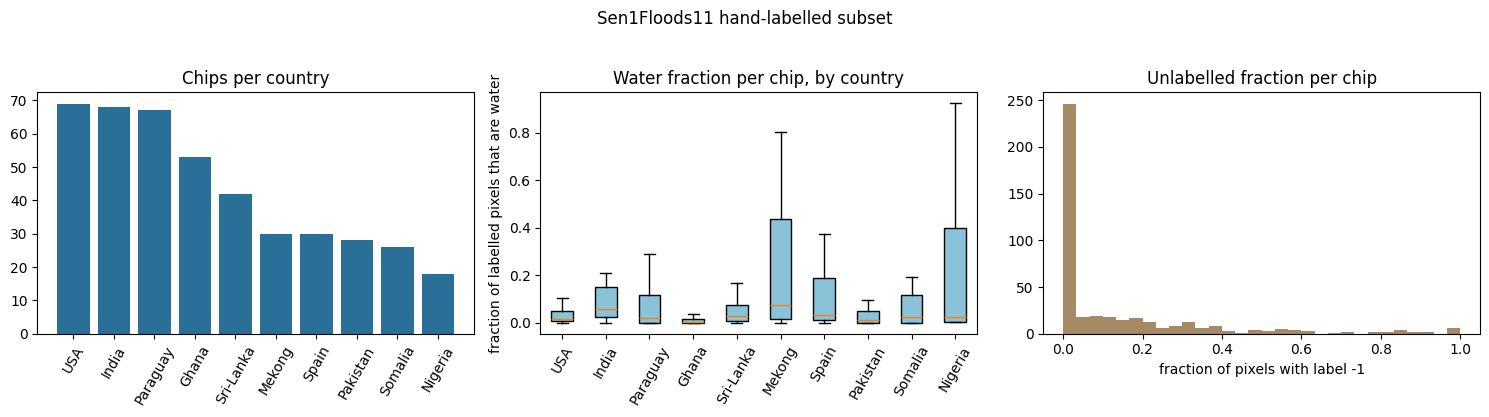

In [18]:


figure, axes = plt.subplots(1, 3, figsize=(15, 4))

order = label_stats["country"].value_counts().index
axes[0].bar(order, label_stats["country"].value_counts().loc[order].values, color="#2a6f97")
axes[0].set_title("Chips per country")
axes[0].tick_params(axis="x", rotation=60)

grouped = [label_stats.loc[label_stats.country == c, "water_frac"].dropna().values for c in order]
axes[1].boxplot(grouped, tick_labels=list(order), showfliers=False,
                patch_artist=True, boxprops=dict(facecolor="#89c2d9"))
axes[1].set_title("Water fraction per chip, by country")
axes[1].set_ylabel("fraction of labelled pixels that are water")
axes[1].tick_params(axis="x", rotation=60)

axes[2].hist(label_stats["unlabelled_frac"], bins=30, color="#a68a64")
axes[2].set_title("Unlabelled fraction per chip")
axes[2].set_xlabel("fraction of pixels with label -1")

figure.suptitle("Sen1Floods11 hand-labelled subset", y=1.03)
plt.tight_layout()
plt.show()

### 3.5 Optical, radar, label, side by side

**In the images:** optical is easy for your eye. Radar is not. Water is darker, but so are roads, dry sand and shadow. Wherever radar looks dark and the label says dry, that is a false alarm waiting to happen.

**In the histogram:** if the two classes separated cleanly, a fixed threshold would solve flood mapping and this notebook would end here. They overlap. The printed number is the fraction of water pixels inside that overlap, and those are the pixels a model can get right where a threshold cannot.

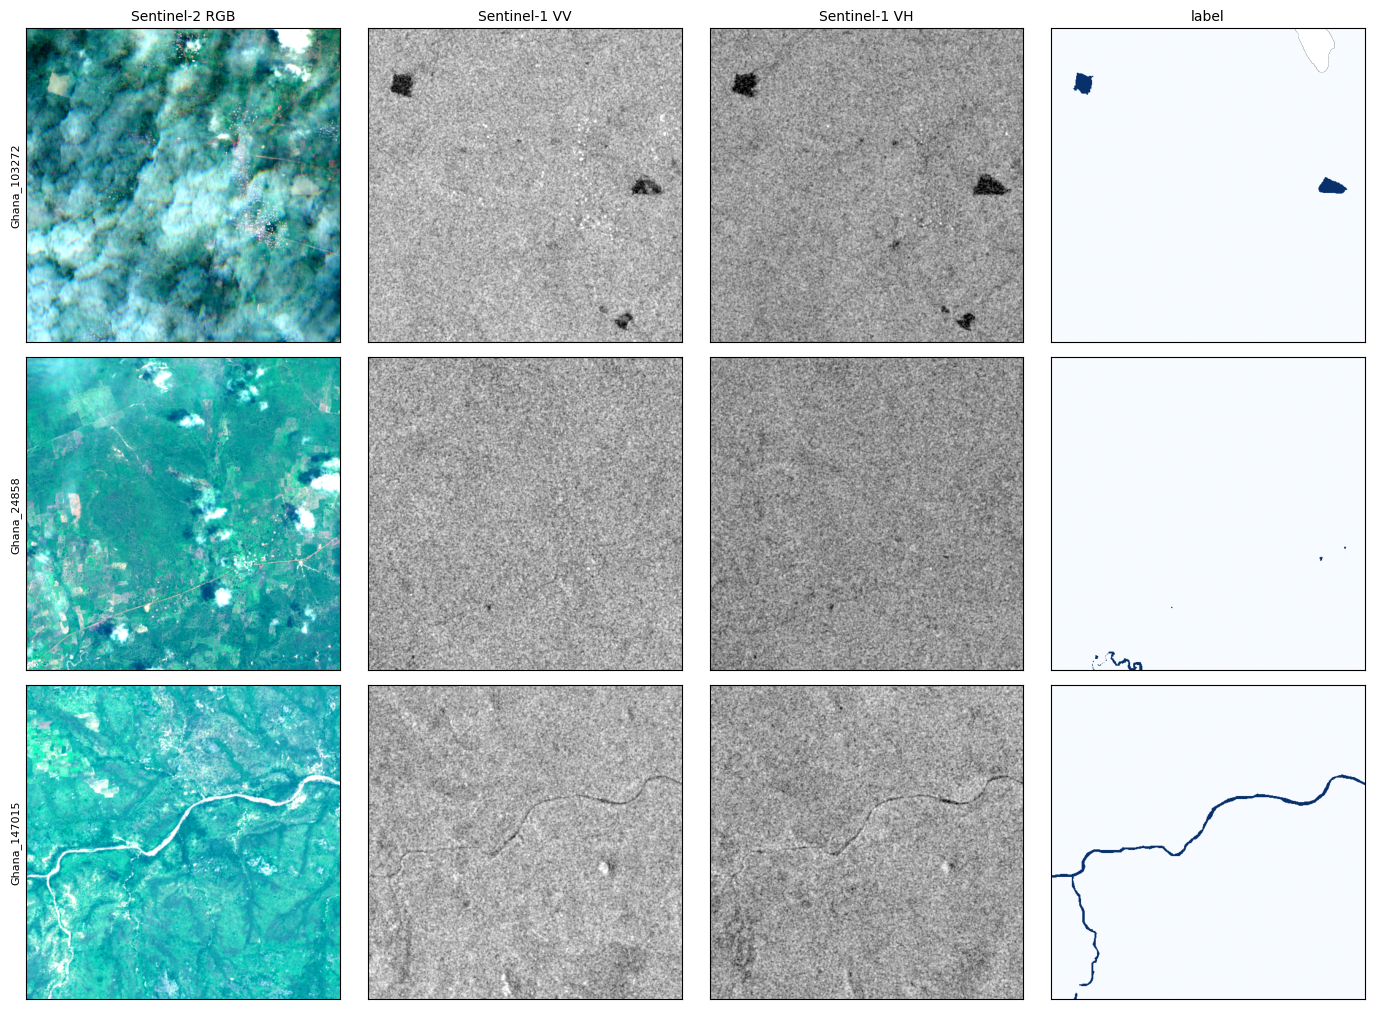

In [19]:
sample_chips = catalogue["chip"].drop_duplicates().tolist()[:3]

figure, axes = plt.subplots(len(sample_chips), 4, figsize=(14, 3.4 * len(sample_chips)))
axes = np.atleast_2d(axes)

water_values, land_values = [], []

for row, chip_id in enumerate(sample_chips):
    with rasterio.open(find_file(chip_id, "S1GRDHand", "*_S1*.tif")) as src:
        radar = np.where(src.read().astype("float32") < -80, np.nan, src.read().astype("float32"))
    with rasterio.open(find_file(chip_id, "S2L1CHand", "*_S2*.tif")) as src:
        optical = src.read().astype("float32")
    with rasterio.open(find_file(chip_id, "LabelHand", "*_Label*.tif")) as src:
        label = src.read(1).astype("int16")

    usable = (label >= 0) & np.isfinite(radar).all(axis=0)
    water_values.append(radar[1][usable & (label == 1)])
    land_values.append(radar[1][usable & (label == 0)])

    rgb = optical[[3, 2, 1]].transpose(1, 2, 0)
    low, high = np.percentile(rgb, [2, 98])
    axes[row, 0].imshow(np.clip((rgb - low) / max(high - low, 1e-6), 0, 1))
    axes[row, 1].imshow(np.clip(radar[0], -25, -2), cmap="gray")
    axes[row, 2].imshow(np.clip(radar[1], -30, -5), cmap="gray")
    axes[row, 3].imshow(np.where(label >= 0, label, np.nan), cmap="Blues", vmin=0, vmax=1)

    if row == 0:
        for column, title in enumerate(["Sentinel-2 RGB", "Sentinel-1 VV", "Sentinel-1 VH", "label"]):
            axes[row, column].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(chip_id, fontsize=8)
    for column in range(4):
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])

plt.tight_layout()
plt.show()

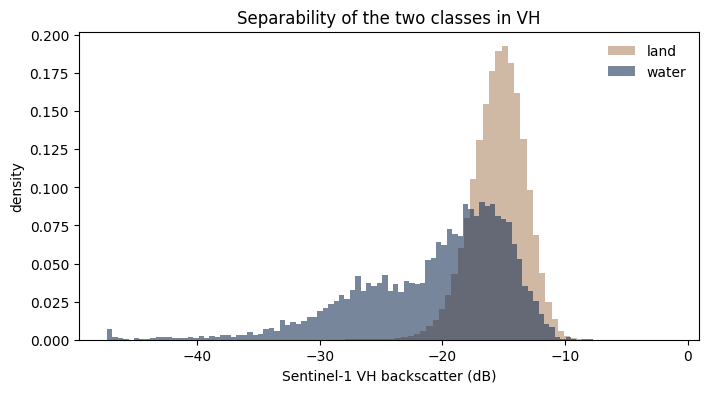

median VH over water : -19.1 dB
median VH over land  : -15.3 dB

50.3% of water pixels are brighter than the darkest 5 percent of land pixels.
Those are the pixels a fixed threshold cannot resolve, and the reason a model is used.


In [20]:


water_values = np.concatenate(water_values)
land_values = np.concatenate(land_values)

figure, axis = plt.subplots(figsize=(8, 4))
axis.hist(land_values, bins=90, density=True, alpha=0.6, color="#b08968", label="land")
axis.hist(water_values, bins=90, density=True, alpha=0.6, color="#1d3557", label="water")
axis.set_xlabel("Sentinel-1 VH backscatter (dB)")
axis.set_ylabel("density")
axis.set_title("Separability of the two classes in VH")
axis.legend(frameon=False)
plt.show()

print(f"median VH over water : {np.median(water_values):.1f} dB")
print(f"median VH over land  : {np.median(land_values):.1f} dB")
threshold = np.percentile(land_values, 5)
print(f"\n{np.mean(water_values > threshold):.1%} of water pixels are brighter than the "
      "darkest 5 percent of land pixels.")
print("Those are the pixels a fixed threshold cannot resolve, and the reason a model is used.")

## Part 4. Baselines: Simple CNN and U-Net

Before touching a foundation model, build something ordinary. Without a baseline, any number the foundation model produces is meaningless.

Three baselines, cheapest first:

| Method | Training | What it represents |
| --- | --- | --- |
| Otsu threshold | none | The classical operational method, used for decades |
| Simple CNN | ~2 min | Deep learning with a small field of view |
| U-Net | ~4 min | Deep learning with multi-scale context |

All three use **Sentinel-1 only**, the **same official splits**, and the **same normalisation** as TerraMind. That makes the final comparison fair.

This is not a straw man. PANGAEA evaluated twelve geospatial foundation models on this exact dataset and found a plain supervised U-Net beat all of them (Marsocci et al., 2024).

### 4.1 Loading the chips

A small PyTorch dataset. It reads the two radar bands and the label, replaces the nodata sentinel, and standardises with TerraMind's pretraining values so every model sees identically scaled input.

In [23]:
import torch
import torch.nn as nn
import numpy as np
import rasterio
from torch.utils.data import Dataset, DataLoader

EPOCHS = 10        # raise this if you have time. 10 is enough to make the point.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

# TerraMind's pre-training statistics, exactly as the data module uses them.
S2_MEAN = np.array([2357.089, 2137.385, 2018.788, 2082.986, 2295.651, 2854.537,
                    3122.849, 3040.560, 3306.481, 1473.847, 506.070, 2472.825,
                    1838.929], dtype="float32")
S2_STD = np.array([1624.683, 1675.806, 1557.708, 1833.702, 1823.738, 1733.977,
                   1732.131, 1679.732, 1727.260, 1024.687, 442.165, 1331.411,
                   1160.419], dtype="float32")
S1_MEAN = np.array([-12.599, -20.293], dtype="float32")
S1_STD = np.array([5.195, 5.890], dtype="float32")

# Channel order: 13 optical bands first, then VV and VH.
ALL_MEAN = np.concatenate([S2_MEAN, S1_MEAN])
ALL_STD = np.concatenate([S2_STD, S1_STD])
N_CHANNELS = len(ALL_MEAN)


class FloodChips(Dataset):
    """Loads Sentinel-2 and Sentinel-1 together, the same 15 channels TerraMind sees."""

    def __init__(self, chip_ids):
        self.chip_ids = chip_ids

    def __len__(self):
        return len(self.chip_ids)

    def __getitem__(self, position):
        chip_id = self.chip_ids[position]

        with rasterio.open(find_file(chip_id, "S2L1CHand", "*_S2*.tif")) as source:
            optical = source.read().astype("float32")

        with rasterio.open(find_file(chip_id, "S1GRDHand", "*_S1*.tif")) as source:
            radar = source.read().astype("float32")

        with rasterio.open(find_file(chip_id, "LabelHand", "*_Label*.tif")) as source:
            label = source.read(1).astype("float32")

        radar[radar < -80] = S1_MEAN[0]          # radar nodata sentinel
        image = np.concatenate([optical, radar], axis=0)
        image[~np.isfinite(image)] = 0.0

        image = (image - ALL_MEAN[:, None, None]) / ALL_STD[:, None, None]
        return torch.from_numpy(image), torch.from_numpy(label)


train_data = FloodChips(splits["train"])
val_data = FloodChips(splits["val"])
test_data = FloodChips(splits["test"])

train_loader = DataLoader(train_data, batch_size=4, shuffle=True, drop_last=True)
baseline_test_loader = DataLoader(test_data, batch_size=4)

print("train chips:", len(train_data), " test chips:", len(test_data))
one_image, one_label = train_data[0]
print("one sample:", tuple(one_image.shape), "input,", tuple(one_label.shape), "label")
print("channels:", N_CHANNELS, "= 13 optical + 2 radar")

Training on: cuda
train chips: 252  test chips: 90
one sample: (15, 512, 512) input, (512, 512) label
channels: 15 = 13 optical + 2 radar


### 4.2 The two networks

**Simple CNN.** Three convolutions, no shrinking. Each output pixel sees only a 7 by 7 window around it. It can learn "dark and smooth means water" but knows nothing about the shape of the scene.

**U-Net.** Shrinks the image twice so the middle layers see the whole scene, then grows it back. Skip connections carry the fine detail across so the edges stay sharp. This shape has been the default for segmentation since 2015.

The interesting part is the parameter counts. The U-Net has roughly ten times more, and the question is whether that buys anything.

In [24]:
class SimpleCNN(nn.Module):
    """Three convolutions. Every pixel is judged on a 7 by 7 window around it."""

    def __init__(self, channels_in=N_CHANNELS):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(channels_in, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.layers(x)


class UNet(nn.Module):
    """Shrinks the image twice to see context, then grows it back, keeping the details."""

    def __init__(self, channels_in=N_CHANNELS, width=16):
        super().__init__()

        def two_convs(a, b):
            return nn.Sequential(
                nn.Conv2d(a, b, 3, padding=1), nn.BatchNorm2d(b), nn.ReLU(),
                nn.Conv2d(b, b, 3, padding=1), nn.BatchNorm2d(b), nn.ReLU(),
            )

        self.down1 = two_convs(channels_in, width)
        self.down2 = two_convs(width, width * 2)
        self.bottom = two_convs(width * 2, width * 4)
        self.shrink = nn.MaxPool2d(2)
        self.grow2 = nn.ConvTranspose2d(width * 4, width * 2, 2, stride=2)
        self.up2 = two_convs(width * 4, width * 2)
        self.grow1 = nn.ConvTranspose2d(width * 2, width, 2, stride=2)
        self.up1 = two_convs(width * 2, width)
        self.final = nn.Conv2d(width, 1, 1)

    def forward(self, x):
        skip1 = self.down1(x)
        skip2 = self.down2(self.shrink(skip1))
        middle = self.bottom(self.shrink(skip2))
        x = self.up2(torch.cat([self.grow2(middle), skip2], dim=1))
        x = self.up1(torch.cat([self.grow1(x), skip1], dim=1))
        return self.final(x)


def count_parameters(model):
    total = 0
    for one_parameter in model.parameters():
        total = total + one_parameter.numel()
    return total


print("Input channels       :", N_CHANNELS)
print("Simple CNN parameters:", count_parameters(SimpleCNN()))
print("U-Net parameters     :", count_parameters(UNet()))

Input channels       : 15
Simple CNN parameters: 14017
U-Net parameters     : 119409


### 4.3 Training both

Same loss, same optimiser, same number of epochs, so the only difference is the architecture.

The loss ignores `-1` pixels. That is the `counts_in_loss` mask, and it is the single most common thing people get wrong on this dataset.

About 6 minutes for both on a T4.

In [28]:
def train_model(model, epochs=10):
    """Trains a model and returns it. Unlabelled pixels are left out of the loss."""
    model = model.to(device)
    optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 1 means water, 0 means dry, -1 means the annotator could not tell.
            counts_in_loss = (labels >= 0).float()
            targets = labels.clamp(min=0)

            optimiser.zero_grad()
            predictions = model(images).squeeze(1)

            loss_per_pixel = nn.functional.binary_cross_entropy_with_logits(
                predictions, targets, reduction="none")
            loss = (loss_per_pixel * counts_in_loss).sum() / counts_in_loss.sum()

            loss.backward()
            optimiser.step()

            running_loss = running_loss + float(loss.detach())
            batches = batches + 1

        print("  epoch", epoch + 1, "of", epochs, " loss", round(running_loss / batches, 4))

    return model


def score_model(model):
    """Returns IoU and F1 on the test split, ignoring unlabelled pixels."""
    model.eval()
    true_positive = 0
    false_positive = 0
    false_negative = 0

    with torch.no_grad():
        for images, labels in baseline_test_loader:
            images = images.to(device)
            predictions = torch.sigmoid(model(images).squeeze(1)).cpu().numpy()
            predictions = (predictions >= 0.5)
            labels = labels.numpy()

            usable = labels >= 0
            is_water = (labels == 1) & usable
            said_water = predictions & usable

            true_positive = true_positive + int((is_water & said_water).sum())
            false_positive = false_positive + int((~is_water & said_water).sum())
            false_negative = false_negative + int((is_water & ~said_water).sum())

    iou = true_positive / max(true_positive + false_positive + false_negative, 1)
    f1 = 2 * true_positive / max(2 * true_positive + false_positive + false_negative, 1)
    return {"IoU": round(iou, 3), "F1": round(f1, 3)}


scoreboard = {}

print("Training the simple CNN")
torch.manual_seed(0)
simple_cnn = train_model(SimpleCNN(), epochs=EPOCHS)
scoreboard["Simple CNN"] = score_model(simple_cnn)
print("  result:", scoreboard["Simple CNN"], "\n")

print("Training the U-Net")
torch.manual_seed(0)
unet = train_model(UNet(), epochs=EPOCHS)
scoreboard["U-Net"] = score_model(unet)
print("  result:", scoreboard["U-Net"])

Training the simple CNN
  epoch 1 of 10  loss 0.2452
  epoch 2 of 10  loss 0.1251
  epoch 3 of 10  loss 0.1072
  epoch 4 of 10  loss 0.0934
  epoch 5 of 10  loss 0.1068
  epoch 6 of 10  loss 0.1052
  epoch 7 of 10  loss 0.0912
  epoch 8 of 10  loss 0.0844
  epoch 9 of 10  loss 0.1142
  epoch 10 of 10  loss 0.1062
  result: {'IoU': 0.762, 'F1': 0.865} 

Training the U-Net
  epoch 1 of 10  loss 0.3764
  epoch 2 of 10  loss 0.2423
  epoch 3 of 10  loss 0.189
  epoch 4 of 10  loss 0.1573
  epoch 5 of 10  loss 0.1378
  epoch 6 of 10  loss 0.1375
  epoch 7 of 10  loss 0.1407
  epoch 8 of 10  loss 0.1263
  epoch 9 of 10  loss 0.1297
  epoch 10 of 10  loss 0.1209
  result: {'IoU': 0.765, 'F1': 0.867}


### 4.4 The zero-training baseline



  1. *Otsu's method is an automatic way of choosing a brightness cut-off. Water looks dark to a radar satellite and land looks bright, so a flood map can be made by calling everything below some value water, but the right value differs from scene to scene. Otsu picks it for you: it looks at the histogram of the image, tries every possible cut-off, and keeps the one that makes the two resulting groups as internally uniform as possible, which is the same as making them as different from each other as possible.*

  2. *If the histogram has two humps, one for water and one for land, the cut-off lands in the valley between them*



If your neural network cannot beat this, the network is not the problem, the setup is.

In [29]:
from skimage.filters import threshold_otsu

true_positive = 0
false_positive = 0
false_negative = 0

for chip_id in splits["test"]:
    with rasterio.open(find_file(chip_id, "S1GRDHand", "*_S1*.tif")) as source:
        vh = source.read(2).astype("float32")
    with rasterio.open(find_file(chip_id, "LabelHand", "*_Label*.tif")) as source:
        label = source.read(1)

    usable = (label >= 0) & (vh > -80)
    if usable.sum() < 100:
        continue

    cut_off = threshold_otsu(vh[usable])
    said_water = (vh < cut_off) & usable
    is_water = (label == 1) & usable

    true_positive = true_positive + int((is_water & said_water).sum())
    false_positive = false_positive + int((~is_water & said_water).sum())
    false_negative = false_negative + int((is_water & ~said_water).sum())

otsu_iou = true_positive / max(true_positive + false_positive + false_negative, 1)
otsu_f1 = 2 * true_positive / max(2 * true_positive + false_positive + false_negative, 1)
scoreboard["Otsu threshold"] = {"IoU": round(otsu_iou, 3), "F1": round(otsu_f1, 3)}

print("Otsu threshold, no training at all:", scoreboard["Otsu threshold"])

Otsu threshold, no training at all: {'IoU': 0.23, 'F1': 0.374}


### 4.5 What they produce

Look at the maps, not just the numbers.

- The simple CNN is usually noisy and speckled. Small field of view, no sense of the scene.
- The U-Net is smoother with cleaner edges, because it saw the whole image.

That difference is often visible before it shows up in the IoU, which is one reason flood mapping evaluation is argued about.

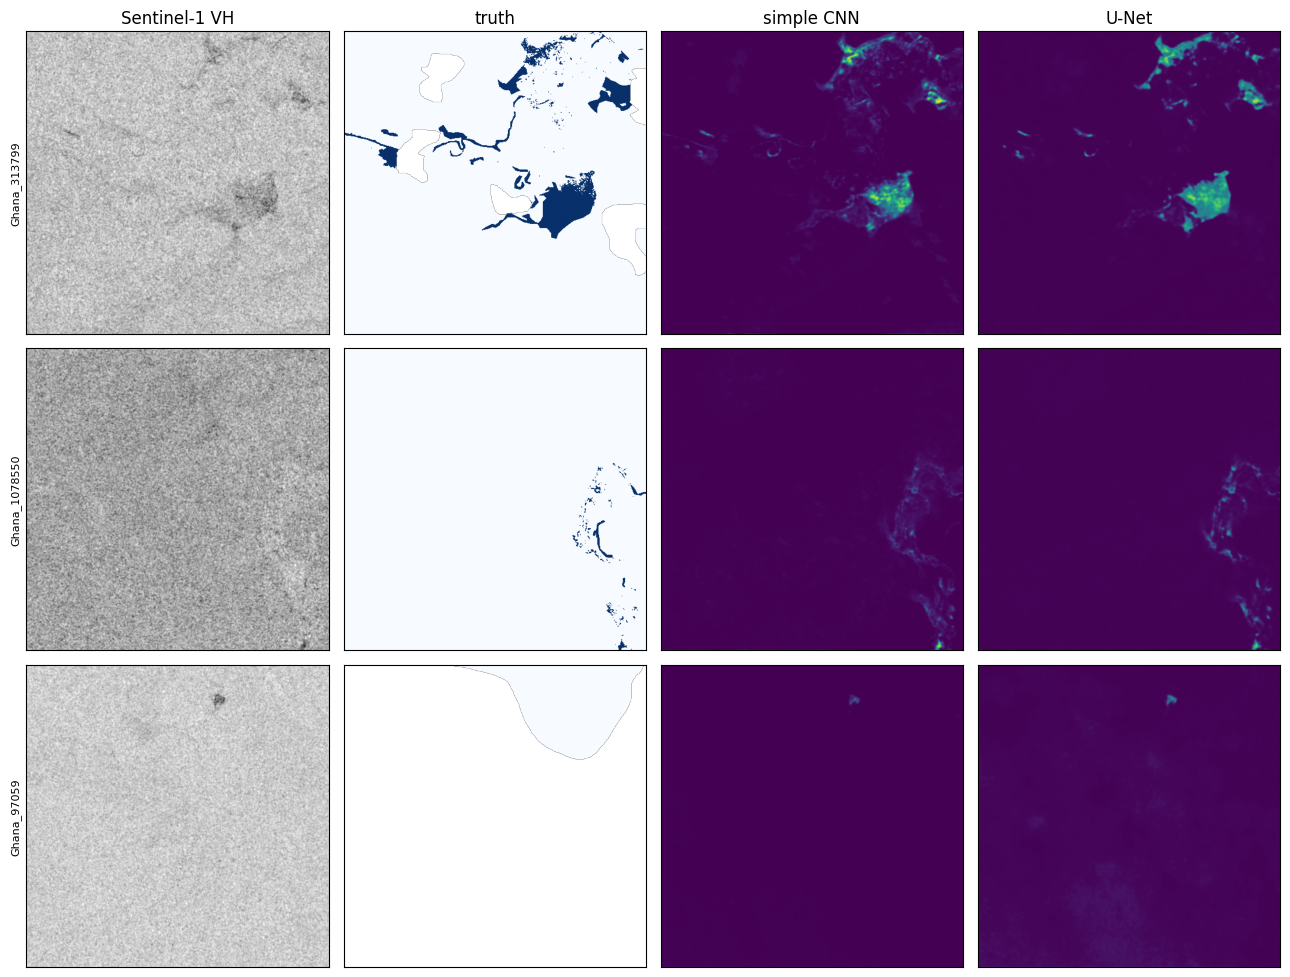

In [30]:
import matplotlib.pyplot as plt

chips_to_show = splits["test"][:3]

figure, panels = plt.subplots(len(chips_to_show), 4, figsize=(13, 3.3 * len(chips_to_show)))
panels = np.atleast_2d(panels)

for row in range(len(chips_to_show)):
    chip_id = chips_to_show[row]
    image, label = FloodChips([chip_id])[0]

    with torch.no_grad():
        batch = image.unsqueeze(0).to(device)
        cnn_map = torch.sigmoid(simple_cnn(batch).squeeze()).cpu().numpy()
        unet_map = torch.sigmoid(unet(batch).squeeze()).cpu().numpy()

    label = label.numpy()

    panels[row, 0].imshow(image[14].numpy(), cmap="gray")   # channel 14 is VH
    panels[row, 1].imshow(np.where(label >= 0, label, np.nan), cmap="Blues", vmin=0, vmax=1)
    panels[row, 2].imshow(cnn_map, cmap="viridis", vmin=0, vmax=1)
    panels[row, 3].imshow(unet_map, cmap="viridis", vmin=0, vmax=1)

    if row == 0:
        panels[row, 0].set_title("Sentinel-1 VH")
        panels[row, 1].set_title("truth")
        panels[row, 2].set_title("simple CNN")
        panels[row, 3].set_title("U-Net")

    panels[row, 0].set_ylabel(chip_id, fontsize=8)
    for column in range(4):
        panels[row, column].set_xticks([])
        panels[row, column].set_yticks([])

plt.tight_layout()
plt.show()

## Part 5. Fine-tuning from a Config File

Now the foundation model. Everything from here to Part 11 is one workflow, written two ways: as a YAML file that runs in one command, then in Python so you can see what each setting does.

**Why config files matter.** A fine-tuning run has around forty settings that change the result. A number reported without them cannot be reproduced. A YAML file carries all of them in one artefact you can commit or attach to a paper.

Two notes:

- Run `terratorch fit` in a terminal on a local machine. Notebook kernels handle multi-process data loaders badly.
- The downloaded config is for the **tiny** model. The Python version below uses **small**. Same workflow, different size.



### What a foundation model is

A large network trained on a huge unlabelled corpus with a self-supervised objective, usually reconstructing masked parts of its own input. It never sees a task label during pretraining. What it produces is a general representation of satellite imagery.

The argument is economic: satellite imagery is unlimited and free, labelled satellite imagery is scarce and expensive. Sen1Floods11 has 446 labelled chips. If most of the visual understanding comes from the unlimited resource, the scarce one only has to teach the last step.

### What makes TerraMind different

- **Multimodal by design.** Pretrained across Sentinel-2 L1C and L2A, Sentinel-1 GRD and RTC, DEM, NDVI, land cover and RGB, learning how they correspond. That is why it takes radar and optical together.
- **Generative as well.** It can synthesise one modality from another, which is what the `_tim` variants in the registry use.

### Sizes, measured

| Variant | Parameters | Layers | Width |
| --- | --- | --- | --- |
| tiny | 6.1 M | 12 | 192 |
| small | 22.8 M | 12 | 384 |
| base | 87.9 M | 12 | 768 |
| large | 305.9 M | 24 | 1024 |

That layer count is why the config selects `[2, 5, 8, 11]` for tiny, small and base, and `[5, 11, 17, 23]` for large. Evenly spaced taps through the depth.

We use `tiny`: big enough for pretraining to be worth something, small enough for a free T4.

### The four-part model

```
backbone  ->  necks  ->  decoder  ->  head
```

**Backbone.** The pretrained encoder. Emits token sequences.

**Necks.** Adapters. A vision transformer gives a flat sequence at one resolution. A U-Net decoder wants a pyramid at four resolutions. Three necks bridge that:

| Neck | Does | Why |
| --- | --- | --- |
| `SelectIndices` | keeps layers 2, 5, 8, 11 | shallow layers hold detail, deep layers hold meaning, a U-Net wants both |
| `ReshapeTokensToImage` | folds each sequence into a 2D grid | 196 tokens become a 14 by 14 map. `remove_cls_token=False` because TerraMind has no CLS token |
| `LearnedInterpolateToPyramidal` | learns upsampling to four scales | the four layers come out the same size, a U-Net needs them different |

Shape mismatch errors in TerraTorch almost always come from here.

**Decoder.** U-Net, `[256, 128, 64, 32]` for tiny and small, `[512, 256, 128, 64]` for base and large.

**Head.** One convolution to 2 classes, with 10 percent dropout.

In [31]:
# Download config
!wget https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/configs/terramind_v1_tiny_sen1floods11.yaml

--2026-09-15 19:37:56--  https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/configs/terramind_v1_tiny_sen1floods11.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3592 (3.5K) [text/plain]
Saving to: ‘terramind_v1_tiny_sen1floods11.yaml’

terramind_v1_tiny_s 100%[===================>]   3.51K  --.-KB/s    in 0s      

2026-09-15 19:37:57 (51.5 MB/s) - ‘terramind_v1_tiny_sen1floods11.yaml’ saved [3592/3592]



Read this before running it. Every key is explained in Parts 6 to 9.

In [32]:
# Check the config
!cat terramind_v1_tiny_sen1floods11.yaml

# lightning.pytorch==2.1.1
seed_everything: 42
trainer:
  accelerator: auto
  strategy: auto
  devices: auto
  num_nodes: 1
  precision: 16-mixed
  logger: true
  callbacks:
    - class_path: RichProgressBar
    - class_path: LearningRateMonitor
      init_args:
        logging_interval: epoch
  max_epochs: 100
  log_every_n_steps: 5
  default_root_dir: output/terramind_tiny_sen1floods11/

data:
  class_path: terratorch.datamodules.GenericMultiModalDataModule
  init_args:
    task: 'segmentation'
    batch_size: 8
    num_workers: 4
    modalities:
      - S2L1C
      - S1GRD
    rgb_modality: S2L1C
    rgb_indices:
      - 3
      - 2
      - 1
    train_data_root:
      S2L1C: sen1floods11_v1.1/data/S2L1CHand
      S1GRD: sen1floods11_v1.1/data/S1GRDHand
    train_label_data_root: sen1floods11_v1.1/data/LabelHand
    val_data_root:
      S2L1C: sen1floods11_v1.1/data/S2L1CHand
      S1GRD: sen1floods11_v1.1/data/S1GRDHand
    val_label_data_root: sen1floods11_v1.1/data/LabelHand
    

One command, one file, one reproducible run.

In [33]:
# # Run fine-tuning
# !terratorch fit -c terramind_v1_tiny_sen1floods11.yaml

Seed set to 42

TerraMind_v1_tiny.pt: downloading bytes:  82% 173M/212M [00:02<00:00, 187MB/s, 12.6MB/s  ]
TerraMind_v1_tiny.pt: reconstructing file:  49% 103M/212M [00:02<00:02, 46.3MB/s]
TerraMind_v1_tiny.pt: downloading bytes: 100% 184M/184M [00:02<00:00, 75.0MB/s, 17.0MB/s  ]
TerraMind_v1_tiny.pt: reconstructing file: 100% 212M/212M [00:02<00:00, 86.6MB/s, 19.7MB/s  ]
/usr/local/lib/python3.13/dist-packages/terratorch/datamodules/generic_multimodal_data_module.py:516: UserWarning: rgb_modality is deprecated and will be removed in a future release. Provide the modalities for plotting as keys in `rgb_indices` with the format {'<modality>': [<band indices>]}.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/cli.py:734: `SemanticSegmentationTask.configure_optimizers` will be overridden by `MyLightningCLI.configure_optimizers`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For 

## Part 6. Changing the Settings

A YAML file is settings inside settings, like folders inside folders. Four top-level sections:

| Section | Controls |
| --- | --- |
| `trainer` | epochs, hardware, logging |
| `data` | where the images are, splits, normalisation |
| `model` | which backbone, which decoder, frozen or not |
| `optimizer`, `lr_scheduler` | learning rate and how it changes |

In Python it becomes a dictionary. To reach something you name the boxes from outside in: the learning rate is `settings["optimizer"]["init_args"]["lr"]`.

In [34]:
import yaml

# Open the config file and read it into Python.
config_file = open("terramind_v1_tiny_sen1floods11.yaml")
settings = yaml.safe_load(config_file)
config_file.close()

# The file has four main sections. Let's see what they are called.
print("The four main sections of the config file:")
for section_name in settings:
    print("   ", section_name)

# Look inside one of them.
print("\nEverything inside the 'trainer' section:")
for key in settings["trainer"]:
    print("   trainer:", key, "=", settings["trainer"][key])

The four main sections of the config file:
    seed_everything
    trainer
    data
    model
    optimizer
    lr_scheduler

Everything inside the 'trainer' section:
   trainer: accelerator = auto
   trainer: strategy = auto
   trainer: devices = auto
   trainer: num_nodes = 1
   trainer: precision = 16-mixed
   trainer: logger = True
   trainer: callbacks = [{'class_path': 'RichProgressBar'}, {'class_path': 'LearningRateMonitor', 'init_args': {'logging_interval': 'epoch'}}]
   trainer: max_epochs = 100
   trainer: log_every_n_steps = 5
   trainer: default_root_dir = output/terramind_tiny_sen1floods11/


Each pair of brackets goes one level deeper.

Note `max_epochs` is 100 here, while the Python trainer later uses 3. The config is set up for a real run, the notebook for a demonstration.

In [36]:
# Reading one setting. Each pair of square brackets goes one level deeper.
print("Number of epochs   :", settings["trainer"]["max_epochs"])
print("Learning rate      :", settings["optimizer"]["init_args"]["lr"])
print("Backbone frozen    :", settings["model"]["init_args"]["freeze_backbone"])
print("Which model        :", settings["model"]["init_args"]["model_args"]["backbone"])
print("Batch size         :", settings["data"]["init_args"]["batch_size"])

Number of epochs   : 100
Learning rate      : 2e-05
Backbone frozen    : True
Which model        : terramind_v1_tiny
Batch size         : 8


### Two ways to change something

**Quick: add a flag.** No editing at all. Dots instead of brackets.

```bash
!terratorch fit -c terramind_v1_tiny_sen1floods11.yaml \
    --trainer.max_epochs=50 \
    --optimizer.init_args.lr=1e-4 \
    --model.init_args.freeze_backbone=false
```

**Careful: copy the file and edit it.** Better when changing several things, and you end up with a file you can keep.

Only the block at the top of the next cell needs your attention. It prints before and after so you can check.

It also handles one trap for you: the large model has 24 layers where the others have 12, so the layers the decoder taps into have to move.

In [37]:
# ----------------- CHANGE THESE SETTINGS -----------------
MY_EPOCHS = 30                          # how many times to go through the training data
MY_LEARNING_RATE = 0.0001               # how big a step the model takes when it learns
UNFREEZE_THE_BACKBONE = True            # True lets the foundation model itself learn too
MY_MODEL_SIZE = "terramind_v1_small"    # tiny, small, base or large
MY_BATCH_SIZE = 8                       # how many images at a time. Lower this if memory runs out
MY_OUTPUT_FOLDER = "output/my_run/"     # where the results get saved
# ---------------------------------------------------------


# Read the original file again, so that we always start from a clean copy.
config_file = open("terramind_v1_tiny_sen1floods11.yaml")
settings = yaml.safe_load(config_file)
config_file.close()

print("Before:")
print("   epochs        :", settings["trainer"]["max_epochs"])
print("   learning rate :", settings["optimizer"]["init_args"]["lr"])
print("   frozen        :", settings["model"]["init_args"]["freeze_backbone"])
print("   model         :", settings["model"]["init_args"]["model_args"]["backbone"])

# Now put our choices in.
settings["trainer"]["max_epochs"] = MY_EPOCHS
settings["trainer"]["default_root_dir"] = MY_OUTPUT_FOLDER
settings["optimizer"]["init_args"]["lr"] = MY_LEARNING_RATE
settings["data"]["init_args"]["batch_size"] = MY_BATCH_SIZE

# freeze_backbone is the opposite of unfreeze, so we flip it round.
if UNFREEZE_THE_BACKBONE:
    settings["model"]["init_args"]["freeze_backbone"] = False
else:
    settings["model"]["init_args"]["freeze_backbone"] = True

settings["model"]["init_args"]["model_args"]["backbone"] = MY_MODEL_SIZE

# The large model has 24 layers instead of 12, so the layers we tap have to move.
# The next few lines handle that for you.
if MY_MODEL_SIZE == "terramind_v1_large":
    which_layers = [5, 11, 17, 23]
    decoder_sizes = [512, 256, 128, 64]
elif MY_MODEL_SIZE == "terramind_v1_base":
    which_layers = [2, 5, 8, 11]
    decoder_sizes = [512, 256, 128, 64]
else:
    which_layers = [2, 5, 8, 11]
    decoder_sizes = [256, 128, 64, 32]

# Find the neck called SelectIndices and give it the right layer numbers.
list_of_necks = settings["model"]["init_args"]["model_args"]["necks"]
for one_neck in list_of_necks:
    if one_neck["name"] == "SelectIndices":
        one_neck["indices"] = which_layers

settings["model"]["init_args"]["model_args"]["decoder_channels"] = decoder_sizes

print("\nAfter:")
print("   epochs        :", settings["trainer"]["max_epochs"])
print("   learning rate :", settings["optimizer"]["init_args"]["lr"])
print("   frozen        :", settings["model"]["init_args"]["freeze_backbone"])
print("   model         :", settings["model"]["init_args"]["model_args"]["backbone"])
print("   layers tapped :", which_layers)
print("   decoder sizes :", decoder_sizes)

Before:
   epochs        : 100
   learning rate : 2e-05
   frozen        : True
   model         : terramind_v1_tiny

After:
   epochs        : 30
   learning rate : 0.0001
   frozen        : False
   model         : terramind_v1_small
   layers tapped : [2, 5, 8, 11]
   decoder sizes : [256, 128, 64, 32]


Writes a new file and leaves the original alone.

In [38]:
# Save our changed settings into a brand new file.
new_file = open("my_config.yaml", "w")
yaml.safe_dump(settings, new_file, sort_keys=False)
new_file.close()

print("Saved as my_config.yaml")
print("\nThe first 25 lines of the new file:\n")

new_file = open("my_config.yaml")
all_lines = new_file.readlines()
new_file.close()

line_number = 0
for line in all_lines:
    print(line.rstrip())
    line_number = line_number + 1
    if line_number == 25:
        break

Saved as my_config.yaml

The first 25 lines of the new file:

seed_everything: 42
trainer:
  accelerator: auto
  strategy: auto
  devices: auto
  num_nodes: 1
  precision: 16-mixed
  logger: true
  callbacks:
  - class_path: RichProgressBar
  - class_path: LearningRateMonitor
    init_args:
      logging_interval: epoch
  max_epochs: 30
  log_every_n_steps: 5
  default_root_dir: output/my_run/
data:
  class_path: terratorch.datamodules.GenericMultiModalDataModule
  init_args:
    task: segmentation
    batch_size: 8
    num_workers: 4
    modalities:
    - S2L1C
    - S1GRD


Commented out so a long run does not start while you are reading. With the backbone unfrozen and 50 epochs, expect a couple of hours on a T4.

In [39]:
# Remove the # from the line below when you want to actually run it.
# !terratorch fit -c terramind_v1_tiny_sen1floods11.yaml

!terratorch fit -c my_config.yaml

print("When you are ready, delete the # in front of the terratorch line above.")

Seed set to 42

TerraMind_v1_small.pt: downloading bytes:  79% 397M/504M [00:03<00:00, 197MB/s, 33.8MB/s  ]
TerraMind_v1_small.pt: downloading bytes:  84% 425M/504M [00:03<00:00, 176MB/s, 35.5MB/s  ]
TerraMind_v1_small.pt: reconstructing file:  67% 336M/504M [00:03<00:01, 107MB/s, 24.8MB/s  ]
TerraMind_v1_small.pt: downloading bytes:  90% 453M/504M [00:03<00:00, 142MB/s, 37.7MB/s  ]
TerraMind_v1_small.pt: downloading bytes: 100% 464M/464M [00:03<00:00, 120MB/s, 38.9MB/s  ]
TerraMind_v1_small.pt: reconstructing file: 100% 504M/504M [00:03<00:00, 130MB/s, 44.2MB/s  ]
/usr/local/lib/python3.13/dist-packages/terratorch/datamodules/generic_multimodal_data_module.py:516: UserWarning: rgb_modality is deprecated and will be removed in a future release. Provide the modalities for plotting as keys in `rgb_indices` with the format {'<modality>': [<band indices>]}.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/cli.py:734: `SemanticSegmentationTask.configure_optimizers`

### Settings worth knowing

| To change | Where |
| --- | --- |
| Epochs | `settings["trainer"]["max_epochs"]` |
| Learning rate | `settings["optimizer"]["init_args"]["lr"]` |
| Let the backbone learn | `settings["model"]["init_args"]["freeze_backbone"]` |
| Model size | `settings["model"]["init_args"]["model_args"]["backbone"]` |
| Decoder width | `settings["model"]["init_args"]["model_args"]["decoder_channels"]` |
| Which satellites | `settings["data"]["init_args"]["modalities"]` |
| Batch size | `settings["data"]["init_args"]["batch_size"]` |
| Your own splits | `settings["data"]["init_args"]["train_split"]` and the val and test versions |

**Two traps.** Pick `terramind_v1_large` and the layer numbers must become `[5, 11, 17, 23]`. Cut the input bands with `output_bands` and the `means` and `stds` lists must shrink to match, because normalisation is applied band by band in order.

### Learning rate matters more than you think

Kaushik et al. (2025) found results varying by up to **51 percent mIoU** across learning rates on the same data. One guess is not enough.

The cell below writes one config per learning rate. Leave `ACTUALLY_RUN_THEM = False` to see the files without waiting hours.

In [ ]:
ACTUALLY_RUN_THEM = False          # set to True when you have time to spare

learning_rates_to_try = [0.00001, 0.00003, 0.0001]

for one_rate in learning_rates_to_try:

    # Start from a fresh copy of the original each time.
    config_file = open("terramind_v1_tiny_sen1floods11.yaml")
    settings = yaml.safe_load(config_file)
    config_file.close()

    settings["optimizer"]["init_args"]["lr"] = one_rate
    settings["trainer"]["max_epochs"] = 50

    # Give each run its own folder so the results do not overwrite each other.
    folder_name = "output/lr_" + str(one_rate) + "/"
    settings["trainer"]["default_root_dir"] = folder_name

    file_name = "config_lr_" + str(one_rate) + ".yaml"
    new_file = open(file_name, "w")
    yaml.safe_dump(settings, new_file, sort_keys=False)
    new_file.close()

    print("Made", file_name, "which saves its results into", folder_name)

    if ACTUALLY_RUN_THEM:
        print("   running it now, this will take a while ...")
        os.system("terratorch fit -c " + file_name)

print("\nDone. Compare the runs afterwards with: %tensorboard --logdir output")

## Part 7. Comparison

Everything on one table, scored the same way.

- Same test chips
- Same 15 input channels
- Same IoU definition and same 0.5 cut-off
- No mixing of your water IoU with Lightning's mIoU, which are different numbers

### 7.1 Load the model Part 5 trained

In [40]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# Part 5 saved a checkpoint somewhere under output/. Find the most recent one.
checkpoint_files = glob.glob("output/**/*.ckpt", recursive=True)

if len(checkpoint_files) == 0:
    print("No checkpoint found. Run the terratorch fit cell in Part 5 first.")
    terramind_model = None
else:
    checkpoint_files.sort(key=os.path.getmtime)
    newest = checkpoint_files[-1]
    print("Using checkpoint:", newest)
    terramind_model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(newest)
    terramind_model = terramind_model.to(device).eval()

Using checkpoint: output/my_run/lightning_logs/version_0/checkpoints/epoch=29-step=930.ckpt


### 7.2 Score it with the same function as the baselines

Our loader stacks 13 optical bands then 2 radar bands. TerraMind wants them back as two named inputs, which is the only translation needed.

In [42]:
def score_terramind(task_model):
    """Scores TerraMind on the same pixels, with the same metric, as the baselines."""
    true_positive = 0
    false_positive = 0
    false_negative = 0

    with torch.no_grad():
        for images, labels in baseline_test_loader:
            images = images.to(device)
            inputs = {"S2L1C": images[:, :13], "S1GRD": images[:, 13:]}

            logits = task_model(inputs).output
            predictions = (torch.argmax(logits, dim=1).cpu().numpy() == 1)

            labels = labels.numpy()
            usable = labels >= 0
            is_water = (labels == 1) & usable
            said_water = predictions & usable

            true_positive = true_positive + int((is_water & said_water).sum())
            false_positive = false_positive + int((~is_water & said_water).sum())
            false_negative = false_negative + int((is_water & ~said_water).sum())

    iou = true_positive / max(true_positive + false_positive + false_negative, 1)
    f1 = 2 * true_positive / max(2 * true_positive + false_positive + false_negative, 1)
    return {"IoU": round(iou, 3), "F1": round(f1, 3)}


if terramind_model is not None:
    scoreboard["TerraMind"] = score_terramind(terramind_model)
    print("TerraMind:", scoreboard["TerraMind"])

TerraMind: {'IoU': 0.807, 'F1': 0.893}


### 7.3 The table

Read it knowing that the baselines trained for `EPOCHS` epochs with every parameter free, while TerraMind ran with a frozen backbone. The data is identical, the training budget is not.

Held-out test split, Sen1Floods11
Same pixels, same metric, same 15 input channels for every method.

                  IoU     F1
Otsu threshold  0.230  0.374
Simple CNN      0.762  0.865
U-Net           0.765  0.867
TerraMind       0.807  0.893


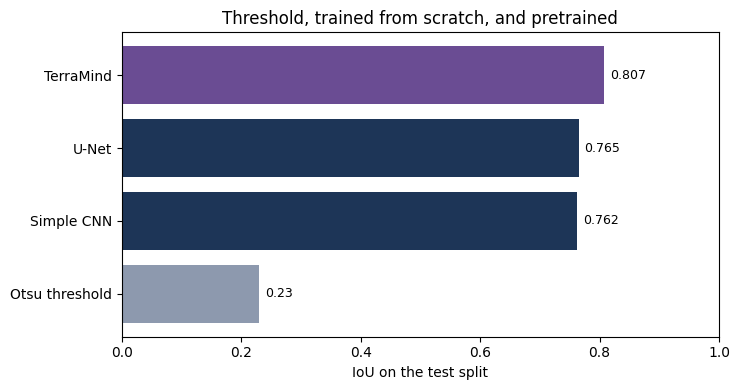

In [43]:
table = pd.DataFrame(scoreboard).T.sort_values("IoU")

print("Held-out test split, Sen1Floods11")
print("Same pixels, same metric, same 15 input channels for every method.\n")
print(table.to_string())

colours = []
for name in table.index:
    if "TerraMind" in name:
        colours.append("#6a4c93")
    elif "Otsu" in name:
        colours.append("#8d99ae")
    else:
        colours.append("#1d3557")

figure, panel = plt.subplots(figsize=(7.5, 4))
panel.barh(table.index, table["IoU"].values, color=colours)
panel.set_xlim(0, 1)
panel.set_xlabel("IoU on the test split")
panel.set_title("Threshold, trained from scratch, and pretrained")
for position in range(len(table)):
    panel.text(table["IoU"].values[position] + 0.01, position,
               str(table["IoU"].values[position]), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Part 8. Where the Models Fail

A single number hides everything useful. Three points:

- Errors along the edge of a large water body mean the model found the water and disagreed about the boundary. Mild.
- Solid blocks of error somewhere unexpected mean something real: dark dry ground read as water, flooded vegetation missed, or a city where radar layover defeated it.
- False alarms and missed water are not equally bad. For evacuation, a miss is far worse.

### 8.1 Pick the chips

In [44]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# red = false alarm, blue = missed water
ERROR_COLOURS = ListedColormap(["#efe8dc", "#e63946", "#457b9d", "#1d3557"])


def predict_baseline(model, image):
    """Water probability map from one of our own networks."""
    with torch.no_grad():
        batch = image.unsqueeze(0).to(device)
        return torch.sigmoid(model(batch).squeeze()).cpu().numpy()


def predict_terramind(task_model, image):
    """Water probability map from the fine-tuned foundation model."""
    with torch.no_grad():
        batch = image.unsqueeze(0).to(device)
        inputs = {"S2L1C": batch[:, :13], "S1GRD": batch[:, 13:]}
        logits = task_model(inputs).output
        return torch.softmax(logits, dim=1)[0, 1].cpu().numpy()


def make_error_map(truth, prediction):
    """0 correct dry, 1 false alarm, 2 missed water, 3 correct water."""
    usable = truth >= 0
    error = np.full(truth.shape, np.nan)
    error[usable & (truth == 0) & (prediction == 0)] = 0
    error[usable & (truth == 0) & (prediction == 1)] = 1
    error[usable & (truth == 1) & (prediction == 0)] = 2
    error[usable & (truth == 1) & (prediction == 1)] = 3
    return error


# Pick three test chips with a decent amount of water, so the pictures are readable.
water_amounts = []
for chip_id in splits["test"]:
    with rasterio.open(find_file(chip_id, "LabelHand", "*_Label*.tif")) as source:
        label = source.read(1)
    usable = label >= 0
    if usable.sum() > 0:
        water_amounts.append((abs(float((label[usable] == 1).mean()) - 0.3), chip_id))
water_amounts.sort()
chips_to_show = [chip_id for _, chip_id in water_amounts[:3]]

print("Showing:", chips_to_show)

Showing: ['Sri-Lanka_713926', 'Spain_7370579', 'Ghana_319168']


### 8.2 The panels

Five columns: radar input, truth, U-Net, TerraMind, and an error map. Red is a false alarm, blue is missed water.

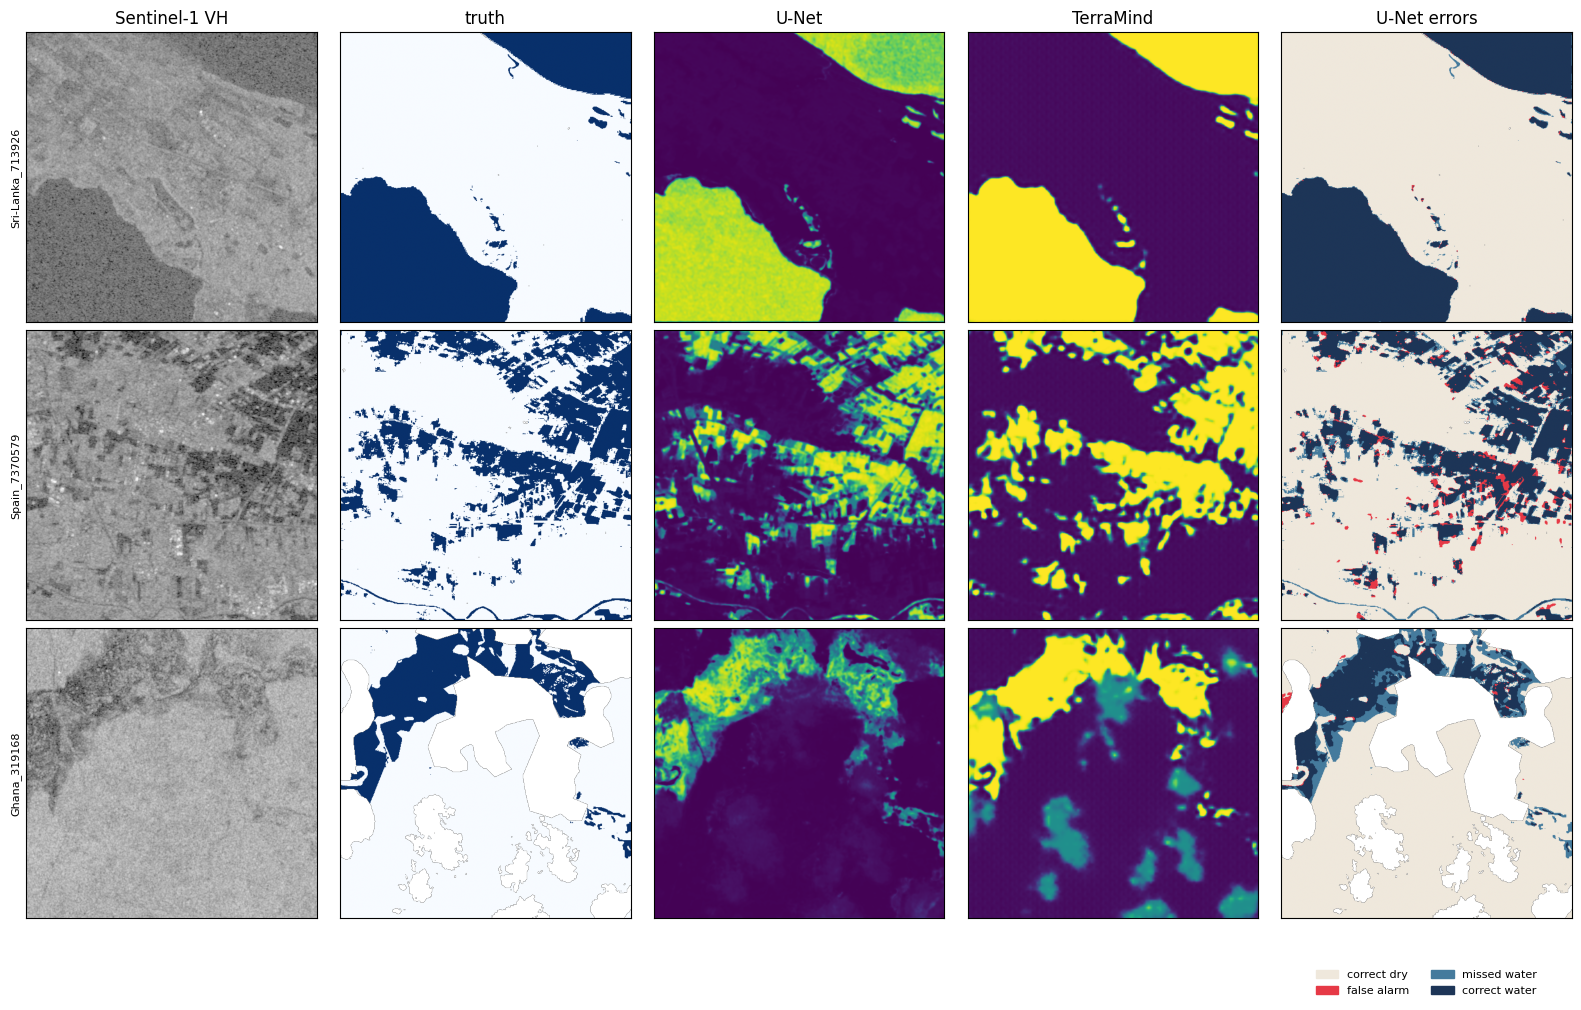

In [45]:
figure, panels = plt.subplots(len(chips_to_show), 5, figsize=(16, 3.3 * len(chips_to_show)))
panels = np.atleast_2d(panels)

for row in range(len(chips_to_show)):
    chip_id = chips_to_show[row]
    image, label = FloodChips([chip_id])[0]
    label = label.numpy()

    unet_map = predict_baseline(unet, image)
    unet_binary = (unet_map >= 0.5).astype("int8")

    if terramind_model is not None:
        terramind_map = predict_terramind(terramind_model, image)
    else:
        terramind_map = np.zeros_like(unet_map)

    panels[row, 0].imshow(image[14].numpy(), cmap="gray")
    panels[row, 1].imshow(np.where(label >= 0, label, np.nan), cmap="Blues", vmin=0, vmax=1)
    panels[row, 2].imshow(unet_map, cmap="viridis", vmin=0, vmax=1)
    panels[row, 3].imshow(terramind_map, cmap="viridis", vmin=0, vmax=1)
    panels[row, 4].imshow(make_error_map(label, unet_binary),
                          cmap=ERROR_COLOURS, vmin=0, vmax=3)

    if row == 0:
        panels[row, 0].set_title("Sentinel-1 VH")
        panels[row, 1].set_title("truth")
        panels[row, 2].set_title("U-Net")
        panels[row, 3].set_title("TerraMind")
        panels[row, 4].set_title("U-Net errors")

    panels[row, 0].set_ylabel(chip_id, fontsize=8)
    for column in range(5):
        panels[row, column].set_xticks([])
        panels[row, column].set_yticks([])

handles = []
for colour in ["#efe8dc", "#e63946", "#457b9d", "#1d3557"]:
    handles.append(plt.Rectangle((0, 0), 1, 1, color=colour))
panels[-1, 4].legend(handles, ["correct dry", "false alarm", "missed water", "correct water"],
                     loc="lower center", bbox_to_anchor=(0.5, -0.30),
                     ncol=2, frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

### 8.3 Count the two kinds of mistake

Same chip, all three methods. A method can have the better IoU and still be the worse choice if its errors fall on the wrong side.

In [46]:
chip_id = chips_to_show[0]
image, label = FloodChips([chip_id])[0]
label = label.numpy()
usable = label >= 0

print("Where each method goes wrong on", chip_id, "\n")

rows = []
for name, prediction in [("U-Net", (predict_baseline(unet, image) >= 0.5)),
                         ("Simple CNN", (predict_baseline(simple_cnn, image) >= 0.5))]:
    is_water = (label == 1) & usable
    said_water = prediction & usable
    rows.append({"method": name,
                 "false alarms": int((~is_water & said_water).sum()),
                 "missed water": int((is_water & ~said_water).sum()),
                 "correct water": int((is_water & said_water).sum())})

if terramind_model is not None:
    prediction = predict_terramind(terramind_model, image) >= 0.5
    is_water = (label == 1) & usable
    said_water = prediction & usable
    rows.append({"method": "TerraMind",
                 "false alarms": int((~is_water & said_water).sum()),
                 "missed water": int((is_water & ~said_water).sum()),
                 "correct water": int((is_water & said_water).sum())})

print(pd.DataFrame(rows).to_string(index=False))

Where each method goes wrong on Sri-Lanka_713926 

    method  false alarms  missed water  correct water
     U-Net           302          1644          78862
Simple CNN           419          1078          79428
 TerraMind          1339           619          79887


## Part 9. Label Efficiency

The experiment the table in Part 7 cannot do.

- Hand labels are the expensive part. Sen1Floods11 has 446 chips, which is nothing.
- The claim for foundation models is not that they win with plenty of labels. It is that they hold up when labels are scarce.
- So retrain the U-Net on 10, 25, 50 and 100 percent of the training chips and plot IoU against label count.

**A flat curve** means labels are not your bottleneck and more annotation will not help. **A steep curve** means they are, and pretraining is worth paying for.

This is the only section here that could become a paper rather than a lesson.

### 9.1 Retrain at four label budgets

Roughly 15 minutes on a T4 at `EPOCHS = 10`.

In [47]:
def make_loader(chip_list, batch_size=4, shuffle=True):
    return DataLoader(FloodChips(chip_list), batch_size=batch_size,
                      shuffle=shuffle, drop_last=shuffle)


def train_on_subset(chip_list, epochs):
    """Trains a fresh U-Net on a subset of the training chips."""
    torch.manual_seed(0)
    model = UNet().to(device)
    optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loader = make_loader(chip_list)

    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            counts_in_loss = (labels >= 0).float()
            targets = labels.clamp(min=0)
            optimiser.zero_grad()
            predictions = model(images).squeeze(1)
            loss_per_pixel = nn.functional.binary_cross_entropy_with_logits(
                predictions, targets, reduction="none")
            loss = (loss_per_pixel * counts_in_loss).sum() / counts_in_loss.sum()
            loss.backward()
            optimiser.step()
    return model


FRACTIONS = [0.10, 0.25, 0.50, 1.00]

all_training_chips = splits["train"]
picker = np.random.default_rng(0)

curve = []
for fraction in FRACTIONS:
    how_many = max(4, int(fraction * len(all_training_chips)))
    chosen = list(picker.choice(all_training_chips, how_many, replace=False))

    model = train_on_subset(chosen, epochs=EPOCHS)
    result = score_model(model)

    curve.append({"fraction": fraction, "chips": how_many,
                  "IoU": result["IoU"], "F1": result["F1"]})
    print(f"{int(fraction*100):3d}% of labels ({how_many:3d} chips) -> IoU {result['IoU']}")

curve = pd.DataFrame(curve)

 10% of labels ( 25 chips) -> IoU 0.771
 25% of labels ( 63 chips) -> IoU 0.808
 50% of labels (126 chips) -> IoU 0.778
100% of labels (252 chips) -> IoU 0.788


### 9.2 The curve

The dashed lines are TerraMind with all labels and Otsu with none, so you can see where the from-scratch U-Net crosses them.

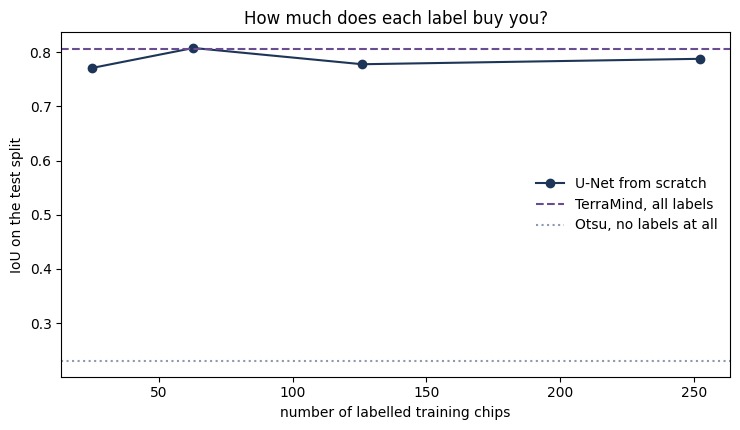

 fraction  chips   IoU    F1
     0.10     25 0.771 0.871
     0.25     63 0.808 0.894
     0.50    126 0.778 0.875
     1.00    252 0.788 0.882

Going from 25 to 252 chips changed IoU by +0.017.
A flat curve means more labels are not the bottleneck. A steep one means they are.


In [48]:
figure, panel = plt.subplots(figsize=(7.5, 4.4))

panel.plot(curve["chips"], curve["IoU"], "o-", color="#1d3557", label="U-Net from scratch")

if "TerraMind" in scoreboard:
    panel.axhline(scoreboard["TerraMind"]["IoU"], color="#6a4c93",
                  linestyle="--", label="TerraMind, all labels")
if "Otsu threshold" in scoreboard:
    panel.axhline(scoreboard["Otsu threshold"]["IoU"], color="#8d99ae",
                  linestyle=":", label="Otsu, no labels at all")

panel.set_xlabel("number of labelled training chips")
panel.set_ylabel("IoU on the test split")
panel.set_title("How much does each label buy you?")
panel.legend(frameon=False)
plt.tight_layout()
plt.show()

print(curve.to_string(index=False))

first = curve["IoU"].iloc[0]
last = curve["IoU"].iloc[-1]
print(f"\nGoing from {curve['chips'].iloc[0]} to {curve['chips'].iloc[-1]} chips "
      f"changed IoU by {last - first:+.3f}.")
print("A flat curve means more labels are not the bottleneck. A steep one means they are.")

## Bonus:   **Predict one scene**

The table says which method is better on average. This says what you actually get for one flood.

Change three things at the top: which chip, which model, and where to draw the line between water and dry. Then read the flooded area in square kilometres, which is the number an emergency manager asks for. Nobody asks for IoU.

Try the same chip with the cut-off at 0.3 and at 0.7. The area moves, sometimes a lot. That is worth seeing, because the map looks equally confident either way.

In [60]:
# ---------------- PICK A CHIP ----------------
CHIP_TO_PREDICT = splits["test"][30]     # change this to any chip name
WHICH_MODEL = "U-Net"                   # "U-Net", "Simple CNN", "TerraMind" or "Otsu"
CUT_OFF = 0.5                           # raise it for fewer false alarms, lower it to miss less
# ---------------------------------------------

image, label = FloodChips([CHIP_TO_PREDICT])[0]
label = label.numpy()

if WHICH_MODEL == "U-Net":
    water_probability = predict_baseline(unet, image)
elif WHICH_MODEL == "Simple CNN":
    water_probability = predict_baseline(simple_cnn, image)
elif WHICH_MODEL == "TerraMind":
    water_probability = predict_terramind(terramind_model, image)
elif WHICH_MODEL == "Otsu":
    with rasterio.open(find_file(CHIP_TO_PREDICT, "S1GRDHand", "*_S1*.tif")) as source:
        vh_raw = source.read(2).astype("float32")
    cut = threshold_otsu(vh_raw[vh_raw > -80])
    water_probability = (vh_raw < cut).astype("float32")
else:
    raise ValueError("WHICH_MODEL must be U-Net, Simple CNN, TerraMind or Otsu")

flood_map = (water_probability >= CUT_OFF).astype("int8")

# Each pixel is 10 m by 10 m, so 100 square metres, or 0.0001 square kilometres.
AREA_PER_PIXEL_KM2 = 0.0001
flooded_pixels = int(flood_map.sum())
flooded_area = flooded_pixels * AREA_PER_PIXEL_KM2

print("Chip      :", CHIP_TO_PREDICT)
print("Model     :", WHICH_MODEL)
print("Cut-off   :", CUT_OFF)
print()
print("Flooded pixels :", f"{flooded_pixels:,}")
print("Flooded area   :", round(flooded_area, 2), "square kilometres")
print("Share of scene :", f"{flood_map.mean():.1%}")

usable = label >= 0
if usable.sum() > 0:
    truth_area = int(((label == 1) & usable).sum()) * AREA_PER_PIXEL_KM2
    correct = int(((label == 1) & (flood_map == 1) & usable).sum())
    missed = int(((label == 1) & (flood_map == 0) & usable).sum())
    false_alarm = int(((label == 0) & (flood_map == 1) & usable).sum())
    iou = correct / max(correct + missed + false_alarm, 1)
    print()
    print("True flooded area :", round(truth_area, 2), "square kilometres")
    print("We over or under estimated by :", round(flooded_area - truth_area, 2), "km2")
    print("IoU on this chip  :", round(iou, 3))

Chip      : Mekong_424793
Model     : U-Net
Cut-off   : 0.5

Flooded pixels : 2,151
Flooded area   : 0.22 square kilometres
Share of scene : 0.8%

True flooded area : 0.4 square kilometres
We over or under estimated by : -0.19 km2
IoU on this chip  : 0.474


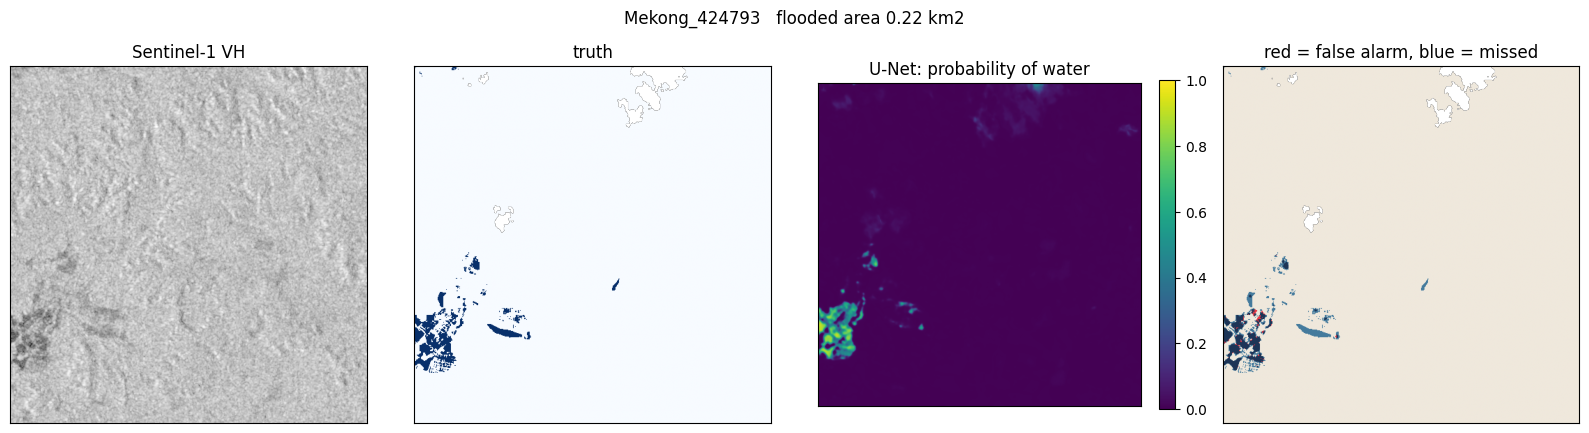

In [61]:
figure, panels = plt.subplots(1, 4, figsize=(16, 4.2))

panels[0].imshow(image[14].numpy(), cmap="gray")
panels[0].set_title("Sentinel-1 VH")

panels[1].imshow(np.where(label >= 0, label, np.nan), cmap="Blues", vmin=0, vmax=1)
panels[1].set_title("truth")

shown = panels[2].imshow(water_probability, cmap="viridis", vmin=0, vmax=1)
panels[2].set_title(WHICH_MODEL + ": probability of water")
figure.colorbar(shown, ax=panels[2], fraction=0.046)

panels[3].imshow(make_error_map(label, flood_map), cmap=ERROR_COLOURS, vmin=0, vmax=3)
panels[3].set_title("red = false alarm, blue = missed")

for panel in panels:
    panel.set_xticks([])
    panel.set_yticks([])

figure.suptitle(CHIP_TO_PREDICT + "   flooded area " + str(round(flooded_area, 2)) + " km2",
                y=1.02)
plt.tight_layout()
plt.show()

## References



> Bonafilia, D., Tellman, B., Anderson, T., and Issenberg, E. (2020). Sen1Floods11: a georeferenced dataset to train and test deep learning flood algorithms for Sentinel-1. IEEE/CVF Conference on Computer Vision and Pattern Recognition Workshops, 835-845.


> Otsu, N. (1979). A threshold selection method from gray-level histograms. IEEE Transactions on Systems, Man, and Cybernetics, 9(1), 62-66.

> Ronneberger, O., Fischer, P., and Brox, T. (2015). U-Net: convolutional networks for biomedical image segmentation. Medical Image Computing and Computer-Assisted Intervention, LNCS 9351, 234-241.

> Jakubik, J., et al. (2025). TerraMind: large-scale generative multimodality for Earth observation. arXiv:2504.11171.

> Gomes, C., et al. (2025). TerraTorch: the geospatial foundation models toolkit. arXiv:2503.20563.






> Paszke, A., et al. (2019). PyTorch: an imperative style, high-performance deep learning library. Advances in Neural Information Processing Systems 32, 8024-8035.





